# HW4: Reinforcement Learning
# Part 1: Planar Drone
Ting-Wei Hsu (twhsu3)

In [ ]:
import numpy as np
from qpsolvers import solve_problem, Problem
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)


## Dynamical System

Consider a planar drone with the equations of motion
$$
\begin{aligned}
\dot{p}_x &= v_x \\
\dot{p}_z &= v_z \\
\dot{\theta} &= \omega \\
m\dot{v}_x &= -(T_1 + T_2)\sin\theta \\
m\dot{v}_z &= (T_1 + T_2)\cos\theta - mg \\
J_y \dot{\omega} &= r(T_1 - T_2)
\end{aligned}
$$

where $m = 0.45$ is the mass; 
$r = 0.14$ is the spar length;
$J_y = 0.09$ is the moment of inertia about the $y$ (out-of-plane) axis;
$g = 9.81$ is the acceleration of gravity;
$p_x$ and $p_z$ are the components of position;
$\theta$ is the orientation;
$v_x$ and $v_z$ are the components of linear velocity;
$\omega$ is the angular velocity;
$T_1$ and $T_2$ are the forces produced by each rotor.

We define the state and input as
$$
x = [p_x,\; p_z,\; \theta,\; v_x,\; v_z,\; \omega]^\top,
 \qquad
u = [T_1,\; T_2]^\top
$$
and the dynamicas as 
$$
\dot{x} = f(x,u)
$$

In [ ]:
m = 0.45
r = 0.14
Jy = 0.09
grav = 9.81
dt = 0.04
N = 25
sim_time = 5.0

x_dim = 6
u_dim = 2

def dynamics(x, u):
    px, pz, theta, vx, vz, omega = x
    T1, T2 = u
    return np.array([
        vx,
        vz,
        omega,
        -(T1 + T2) / m * np.sin(theta),
        (T1 + T2) / m * np.cos(theta) - grav,
        r * (T1 - T2) / Jy,
    ])


def Jacobian_dynamics(x, u):
    _, _, theta, _, _, _ = x
    T1, T2 = u

    A = np.zeros((x_dim, x_dim))
    A[0, 3] = 1.0
    A[1, 4] = 1.0
    A[2, 5] = 1.0
    A[3, 2] = -(T1 + T2) / m * np.cos(theta)
    A[4, 2] = -(T1 + T2) / m * np.sin(theta)

    B = np.zeros((x_dim, u_dim))
    B[3, :] = -(1.0 / m) * np.sin(theta)
    B[4, :] =  (1.0 / m) * np.cos(theta)
    B[5, 0] =  r / Jy
    B[5, 1] = -r / Jy
    return A, B


In [ ]:
x_start = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
x_goal  = np.array([3.0, 0.0, 0.0, 0.0, 0.0, 0.0])
u_ref = np.array([m * grav / 2.0, m * grav / 2.0])

## Gymnasium Environment


In [ ]:

import gymnasium as gym
from gymnasium import spaces


DEFAULT_STATE_LIMIT = np.array([
    [-1.0, 4.0],
    [-1.5, 1.5],
    [-np.pi, np.pi],
    [-6.0, 6.0],
    [-6.0, 6.0],
    [-12.0, 12.0],
], dtype=np.float64)

DEFAULT_OBSTACLE_LIMIT = np.array([
    [0.8, 2.5],
    [-0.8, 0.8],
], dtype=np.float64)


class PlanarQuad(gym.Env):
    """Planar quadrotor reaching task with one circular obstacle.

    The policy action is normalized to [-1, 1]^2. Inside the environment it is
    converted to physical rotor thrusts constrained to [0, 10] N. A normalized
    action of 0 maps to hover thrust so PPO starts from a sensible command.
    """

    metadata = {'render_modes': ['rgb_array'], 'render_fps': 10}

    def __init__(
        self,
        goal=x_goal,
        start=x_start,
        dt=dt,
        max_num_steps=400,
        state_limit=DEFAULT_STATE_LIMIT,
        obstacle_limit=DEFAULT_OBSTACLE_LIMIT,
        dynamics_fn=dynamics,
        random_start=False,
        random_obstacle=True,
        obstacle=None,
        start_noise=np.array([0.03, 0.03, 0.03, 0.05, 0.05, 0.08]),
    ):
        super().__init__()

        self.dt = float(dt)
        self.max_num_steps = int(max_num_steps)
        self.goal = np.array(goal, dtype=np.float64, copy=True)
        self.start = np.array(start, dtype=np.float64, copy=True)
        self.random_start = bool(random_start)
        self.random_obstacle = bool(random_obstacle)
        self.start_noise = np.array(start_noise, dtype=np.float64, copy=True)
        self.dynamics_fn = dynamics_fn

        self.state_limit = np.array(state_limit, dtype=np.float64, copy=True)
        self.obstacle_limit = np.array(obstacle_limit, dtype=np.float64, copy=True)
        self.fixed_obstacle = (
            np.mean(self.obstacle_limit, axis=1)
            if obstacle is None
            else np.array(obstacle, dtype=np.float64, copy=True)
        )

        self.goal_position_tolerance = 0.15
        self.goal_velocity_tolerance = 0.2
        self.goal_angle_tolerance = 0.2
        self.goal_omega_tolerance = 0.25

        self.drone_radius = r
        self.obstacle_radius = r
        self.safety_clearance = 0.35

        self.hover_thrust = np.array(u_ref, dtype=np.float64, copy=True)
        self.min_thrust = 0.0
        self.max_thrust = 10.0

        obs_low = np.concatenate([
            self.state_limit[:, 0],
            self.goal[:2] - self.state_limit[:2, 1],
            self.obstacle_limit[:, 0] - self.state_limit[:2, 1],
        ]).astype(np.float32)
        obs_high = np.concatenate([
            self.state_limit[:, 1],
            self.goal[:2] - self.state_limit[:2, 0],
            self.obstacle_limit[:, 1] - self.state_limit[:2, 0],
        ]).astype(np.float32)
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)
        self.action_space = spaces.Box(
            low=-np.ones(u_dim, dtype=np.float32),
            high=np.ones(u_dim, dtype=np.float32),
            dtype=np.float32,
        )

        self.state = None
        self.obstacle_center = None
        self.step_count = 0
        self.prev_goal_distance = None

    def _wrap_theta(self, theta):
        return ((theta + np.pi) % (2 * np.pi)) - np.pi

    def _get_observation(self):
        goal_rel = self.goal[:2] - self.state[:2]
        obstacle_rel = self.obstacle_center - self.state[:2]
        return np.concatenate([self.state, goal_rel, obstacle_rel]).astype(np.float32)

    def _goal_distance(self):
        return float(np.linalg.norm(self.goal[:2] - self.state[:2]))

    def _obstacle_distance(self):
        return float(np.linalg.norm(self.state[:2] - self.obstacle_center))

    def _state_in_bounds(self, state):
        return bool(np.all(state >= self.state_limit[:, 0]) and np.all(state <= self.state_limit[:, 1]))

    def _in_bounds(self):
        return self._state_in_bounds(self.state)

    def _collision_radius(self):
        return self.drone_radius + self.obstacle_radius

    def _is_success(self):
        return bool(
            self._goal_distance() <= self.goal_position_tolerance
            and np.linalg.norm(self.state[3:5]) <= self.goal_velocity_tolerance
            and abs(self.state[2]) <= self.goal_angle_tolerance
            and abs(self.state[5]) <= self.goal_omega_tolerance
        )

    def _is_collision(self):
        clearance = self._obstacle_distance() - self._collision_radius()
        return self._obstacle_distance() <= self._collision_radius(), clearance

    def _physical_action(self, action):
        normalized_action = np.asarray(action, dtype=np.float64).reshape(-1)
        if normalized_action.size != u_dim:
            raise ValueError(f"Expected action with {u_dim} elements, got {normalized_action.size}")
        normalized_action = np.clip(normalized_action, -1.0, 1.0)
        thrust = np.empty_like(normalized_action)
        for i, a in enumerate(normalized_action):
            if a >= 0.0:
                thrust[i] = self.hover_thrust[i] + a * (self.max_thrust - self.hover_thrust[i])
            else:
                thrust[i] = self.hover_thrust[i] + a * (self.hover_thrust[i] - self.min_thrust)
        thrust = np.clip(thrust, self.min_thrust, self.max_thrust)
        
        return thrust, normalized_action

    def _sample_initial_state(self, random_start=None):
        random_start = self.random_start if random_start is None else bool(random_start)
        if random_start:
            state = self.start.copy()
            state[:2] = self.np_random.uniform(
                self.state_limit[:2, 0] * 0.6,
                self.state_limit[:2, 1] * 0.6,
            )
            state[2] = self.np_random.uniform(-0.4, 0.4)
            state[3:5] = self.np_random.uniform(-0.5, 0.5, size=2)
            state[5] = self.np_random.uniform(-1.0, 1.0)
        else:
            state = self.start + self.np_random.normal(scale=self.start_noise)
        state[2] = self._wrap_theta(state[2])
        return state.astype(np.float64)

    def _sample_obstacle(self):
        return self.np_random.uniform(
            self.obstacle_limit[:, 0],
            self.obstacle_limit[:, 1],
        ).astype(np.float64)

    def _sample_feasible_reset(self, options):
        options = {} if options is None else dict(options)
        min_clearance = self._collision_radius() + 0.25
        random_start = options.get('random_start', self.random_start)
        x0 = options.get('x0')
        obstacle = options.get('obstacle')
        random_obstacle = options.get('random_obstacle', self.random_obstacle)

        for _ in range(1000):
            state = np.array(x0, dtype=np.float64, copy=True) if x0 is not None else self._sample_initial_state(random_start)
            if obstacle is not None:
                candidate_obstacle = np.array(obstacle, dtype=np.float64, copy=True)
            elif random_obstacle:
                candidate_obstacle = self._sample_obstacle()
            else:
                candidate_obstacle = self.fixed_obstacle.copy()
            state[2] = self._wrap_theta(state[2])
            start_clear = np.linalg.norm(state[:2] - candidate_obstacle) > min_clearance
            goal_clear = np.linalg.norm(self.goal[:2] - candidate_obstacle) > min_clearance
            if self._state_in_bounds(state) and start_clear and goal_clear:
                return state, candidate_obstacle
            if x0 is not None or obstacle is not None:
                break
        raise RuntimeError("Could not sample a feasible initial state and obstacle")

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0
        self.state, self.obstacle_center = self._sample_feasible_reset(options)
        self.prev_goal_distance = self._goal_distance()

        return self._get_observation(), {}

    def step(self, action):
        thrust, normalized_action = self._physical_action(action)

        sol = solve_ivp(
            lambda t, y: self.dynamics_fn(y, thrust),
            t_span=[0.0, self.dt],
            y0=self.state,
            t_eval=[self.dt],
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(sol.message)
        self.state = sol.y[:, -1].astype(np.float64)
        self.state[2] = self._wrap_theta(self.state[2])

        goal_distance = self._goal_distance()
        success = self._is_success()
        collision, clearance = self._is_collision()
        out_of_bounds = not self._in_bounds()

        progress = self.prev_goal_distance - goal_distance
        speed = float(np.linalg.norm(self.state[3:5]))
        angle = abs(float(self.state[2]))
        omega = abs(float(self.state[5]))
        effort = float(np.linalg.norm(normalized_action) ** 2)

        reward = 10.0 * progress
        reward -= 0.5 * goal_distance
        reward -= 0.01 * speed
        reward -= 0.03 * angle
        reward -= 0.01 * omega
        reward -= 0.01 * effort

        if goal_distance < 0.75:
            reward += 2.0 * (0.75 - goal_distance) / 0.75
            reward -= 0.5 * speed
            reward -= 0.1 * angle
            reward -= 0.05 * omega
            
            if goal_distance < 0.1:
                reward -= 0.1 * speed
                reward -= 0.05 * angle
                reward -= 0.05 * omega

        if collision:
            reward -= 250.0
        elif clearance < self.safety_clearance:
            reward -= 5.0 * ((self.safety_clearance - clearance) / self.safety_clearance) ** 2

        if success:
            reward += 1000.0
        elif out_of_bounds:
            reward -= 250.0

        self.prev_goal_distance = goal_distance
        self.step_count += 1

        terminated = bool(success or collision or out_of_bounds)
        truncated = bool(self.step_count >= self.max_num_steps and not terminated)
        if truncated:
            reward -= 100.0

        if success:
            termination_reason = 'success'
        elif collision:
            termination_reason = 'collision'
        elif out_of_bounds:
            termination_reason = 'out_of_bounds'
        elif truncated:
            termination_reason = 'timeout'
        else:
            termination_reason = None

        info = {
            'is_success': success,
            'collision': collision,
            'out_of_bounds': out_of_bounds,
            'termination_reason': termination_reason,
            'goal_distance': goal_distance,
            'clearance': clearance,
            'physical_action': thrust.astype(np.float32),
        }

        return self._get_observation(), float(reward), terminated, truncated, info


Test rollouts

In [ ]:

def rollout_random_policy(env, episodes=10, seed=0):
    returns = []
    lengths = []
    final_infos = []

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        final_info = {}

        for step in range(env.max_num_steps):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            final_info = info
            if terminated or truncated:
                break

        returns.append(total_reward)
        lengths.append(step + 1)
        final_infos.append(final_info)
        print(
            f"episode={episode + 1:02d} return={total_reward:8.2f} "
            f"len={step + 1:3d} reason={final_info.get('termination_reason')} "
            f"goal_dist={final_info.get('goal_distance', np.nan):.2f} "
            f"clearance={final_info.get('clearance', np.nan):.2f}"
        )

    return returns, lengths, final_infos

env = PlanarQuad()
obs, info = env.reset(seed=0)
print("observation shape:", obs.shape)
print("action space:", env.action_space)
print("observation space:", env.observation_space)
for test_action in [
    -np.ones(u_dim),
    np.zeros(u_dim),
    np.ones(u_dim),
]:
    print(f"normalized action {test_action} maps to thrust {env._physical_action(test_action)[0]}")

rollout_returns, rollout_lengths, rollout_infos = rollout_random_policy(env, episodes=10, seed=1)


## Training using PPO with Stable-Baselines3

In [ ]:
import math
import os
import json
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
import torch

check_env(PlanarQuad(), warn=True)

# Use Monitor so evaluation logs have episode returns, lengths, and success info.
env = Monitor(PlanarQuad())
eval_env = Monitor(PlanarQuad())

# Stable-Baselines3 expects LR schedules through learning_rate, not policy_kwargs.
# Set num_steps above lr_decay_start_timestep to train into the decay region.
num_steps = 1_000_000
initial_learning_rate = 3e-4
min_learning_rate = 1e-5
lr_decay_start_timestep = 450_000
decay_time_const = 100_000

def delayed_exponential_lr_schedule(progress_remaining: float) -> float:
    current_timestep = (1.0 - progress_remaining) * num_steps
    if current_timestep <= lr_decay_start_timestep:
        return initial_learning_rate

    steps_after_decay_start = current_timestep - lr_decay_start_timestep
    decayed_learning_rate = initial_learning_rate * math.exp(-steps_after_decay_start/decay_time_const)
    return max(min_learning_rate, decayed_learning_rate)

policy_kwargs = dict(
    net_arch=[64, 64, 64],
    activation_fn=torch.nn.ReLU,
)

dirname = 'planarquad_ppo'
os.makedirs(dirname, exist_ok=True)

model = PPO(
    'MlpPolicy',
    env,
    policy_kwargs=policy_kwargs,
    gamma=0.99,
    gae_lambda=0.95,
    learning_rate=delayed_exponential_lr_schedule,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    ent_coef=0.005,
    clip_range=0.2,
    target_kl=0.03,
    verbose=1,
    tensorboard_log=dirname,
    seed=0,
    device='cpu',
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(dirname, 'best_model'),
    log_path=dirname,
    eval_freq=5000,
    n_eval_episodes=10,
    deterministic=True,
)

print(f"Training PPO for {num_steps} steps...")
print(f"Results saved to: {dirname}")
print(f"TensorBoard: tensorboard --logdir {dirname}")
model.learn(total_timesteps=num_steps, callback=eval_callback, log_interval=10)
model.save(os.path.join(dirname, 'final_model'))
print("Model training complete! Final model saved.")


Learning Curves: Plot the evaluation rewards over training timesteps to visualize learning progress.


In [ ]:
results_file_npz = os.path.join(dirname, 'evaluations.npz')

data = np.load(results_file_npz)
timesteps = data['timesteps']
results = data['results']

mean_returns = np.mean(results, axis=1)
std_returns = np.std(results, axis=1)

fig, ax = plt.subplots(1, 1)
ax.plot(timesteps, mean_returns, linewidth=2.5, label='Mean Return', color='blue')
ax.fill_between(
        timesteps,
        mean_returns - std_returns,
        mean_returns + std_returns,
        alpha=0.3,
        color='blue',
        label='+/- 1 Std Dev',
)
ax.set_xlabel('Timesteps', fontsize=12)
ax.set_ylabel('Episode Return', fontsize=12)
ax.set_title('PPO Training Progress: Mean Episodic Return', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(dirname, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

#best_idx = int(np.argmax(mean_returns))
print("\nTraining Statistics:")
print(f"Initial mean return: {mean_returns[0]:.2f}")
print(f"Final mean return: {mean_returns[-1]:.2f}")
#print(f"Best mean return: {mean_returns[best_idx]:.2f} at step {timesteps[best_idx]}")
print(f"Improvement: {mean_returns[-1] - mean_returns[0]:.2f}")


## Example Rollouts using Trained PPO Policy

Run the trained policy on several episodes and visualize the trajectories.


In [99]:
# Choose which model to load
# The best model
best_model_path = os.path.join(dirname, 'best_model', 'best_model.zip')
trained_model = PPO.load(best_model_path, device='cpu')
print(f"Loaded best model: {best_model_path}")

# The final model after all training steps
#final_model_path = os.path.join(dirname, 'final_model.zip')
#trained_model = PPO.load(final_model_path, device='cpu')
#print(f"Loaded final model: {final_model_path}")

import time


def rollout_trained_policy(
    model,
    env=None,
    episodes=20,
    seed=42,
    obstacle_center=None,
    x0=None,
    sim_time=None,
    deterministic=True,
    record_computation_time=False,
    verbose=False,
):
    obstacle_center = None if obstacle_center is None else np.asarray(obstacle_center, dtype=np.float64)
    if obstacle_center is not None and x0 is None:
        x0 = x_start
    x0 = None if x0 is None else np.asarray(x0, dtype=np.float64)

    if env is None:
        env_kwargs = {}
        if sim_time is not None:
            env_kwargs['max_num_steps'] = int(sim_time / dt)
        if obstacle_center is not None:
            env_kwargs.update({
                'random_start': False,
                'random_obstacle': False,
                'obstacle': obstacle_center,
                'start_noise': np.zeros(x_dim),
            })
        elif x0 is not None:
            env_kwargs.update({
                'random_start': False,
                'start_noise': np.zeros(x_dim),
            })
        env = PlanarQuad(**env_kwargs)
    elif sim_time is not None:
        env.max_num_steps = int(sim_time / dt)

    trajectories = []
    returns = []
    termination_counts = {}
    computation_times = []

    for episode in range(episodes):
        reset_options = {}
        if x0 is not None:
            reset_options.update({'x0': x0, 'random_start': False})
        if obstacle_center is not None:
            reset_options.update({'obstacle': obstacle_center, 'random_obstacle': False})

        reset_seed = None if seed is None else seed + episode
        if reset_options:
            obs, _ = env.reset(seed=reset_seed, options=reset_options)
        else:
            obs, _ = env.reset(seed=reset_seed)

        trajectory = {
            'obs': [obs.copy()],
            'states': [env.state.copy()],
            'positions': [env.state[:2].copy()],
            'actions': [],
            'physical_actions': [],
            'rewards': [],
            'success': False,
            'termination_reason': None,
            'final_info': {},
            'obstacle': env.obstacle_center.copy(),
            'obstacle_center': env.obstacle_center.copy(),
        }

        total_reward = 0.0
        final_info = {}
        for step in range(env.max_num_steps):
            if record_computation_time:
                tic = time.perf_counter()
            action, _ = model.predict(obs, deterministic=deterministic)
            if record_computation_time:
                computation_times.append(time.perf_counter() - tic)

            obs, reward, terminated, truncated, info = env.step(action)

            trajectory['obs'].append(obs.copy())
            trajectory['states'].append(env.state.copy())
            trajectory['positions'].append(env.state[:2].copy())
            trajectory['actions'].append(np.asarray(action, dtype=np.float64).copy())
            trajectory['physical_actions'].append(info['physical_action'].copy())
            trajectory['rewards'].append(float(reward))
            total_reward += float(reward)
            final_info = info

            if terminated or truncated:
                break

        reason = final_info.get('termination_reason', 'unknown')
        if verbose:
            print(
                f"rollout {episode + 1:02d}: return={total_reward:8.2f}; "
                f"termination reason={reason} "
            )

        trajectory['termination_reason'] = reason
        trajectory['success'] = bool(final_info.get('is_success', False))
        trajectory['total_reward'] = total_reward
        trajectory['final_info'] = final_info
        trajectory['obs'] = np.asarray(trajectory['obs'])
        trajectory['states'] = np.asarray(trajectory['states'])
        trajectory['positions'] = np.asarray(trajectory['positions'])
        trajectory['actions'] = np.asarray(trajectory['actions'])
        trajectory['physical_actions'] = np.asarray(trajectory['physical_actions'])
        trajectory['rewards'] = np.asarray(trajectory['rewards'])
        trajectory['x_hist'] = trajectory['states']
        trajectory['u_hist'] = trajectory['physical_actions']
        trajectory['action_hist'] = trajectory['actions']

        trajectories.append(trajectory)
        returns.append(total_reward)
        termination_counts[reason] = termination_counts.get(reason, 0) + 1

    computation_time_per_step = np.mean(computation_times) if record_computation_time else None

    if verbose and episodes > 0:
        successes = termination_counts.get('success', 0)
        print(f"Success rate: {successes}/{episodes} ({100 * successes / episodes:.1f}%)")
        #print(f"Mean return: {np.mean(returns):.2f} +/- {np.std(returns):.2f}")

    return trajectories, returns, computation_time_per_step


rollout_env = PlanarQuad()
trajectories, rollout_returns, _ = rollout_trained_policy(trained_model, rollout_env, episodes=10, seed=42, verbose=True)


Loaded best model: planarquad_ppo\best_model\best_model.zip
rollout 01: return= 1003.44; termination reason=success 
rollout 02: return= 1016.43; termination reason=success 
rollout 03: return= 1014.60; termination reason=success 
rollout 04: return= 1000.38; termination reason=success 
rollout 05: return= 1000.21; termination reason=success 
rollout 06: return= 1000.56; termination reason=success 
rollout 07: return=  987.26; termination reason=success 
rollout 08: return= 1002.18; termination reason=success 
rollout 09: return= 1012.43; termination reason=success 
rollout 10: return= 1002.68; termination reason=success 
Success rate: 10/10 (100.0%)


Visualize trajectories of the rollouts

In [ ]:
num_plots = min(len(trajectories), 5)
fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
if num_plots == 1:
    axes = [axes]

for idx, traj in enumerate(trajectories[:num_plots]):
    ax = axes[idx]
    positions = traj['positions']

    ax.plot(positions[:, 0], positions[:, 1], 'b-', linewidth=2, label='Trajectory', alpha=0.75)
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=9, label='Start', zorder=5)
    ax.plot(x_goal[0], x_goal[1], 'r*', markersize=14, label='Goal', zorder=5)

    obstacle_pos = traj['obstacle']
    obstacle = plt.Circle(obstacle_pos, r, color='orange', alpha=0.55, label='Obstacle')
    inflated = plt.Circle(obstacle_pos, 2 * r, color='orange', alpha=0.15, label='Collision buffer')
    ax.add_patch(inflated)
    ax.add_patch(obstacle)

    ax.add_patch(plt.Circle(positions[0], r, color='green', alpha=0.15))
    ax.add_patch(plt.Circle((x_goal[0], x_goal[1]), r, color='red', alpha=0.15))

    ax.set_xlabel('$p_x$ (m)', fontsize=11)
    ax.set_ylabel('$p_z$ (m)', fontsize=11)
    #title = f'Ep {idx + 1}: {traj["termination_reason"]}\nReturn={traj["total_reward"]:.1f}'
    #ax.set_title(title, fontsize=11, fontweight='bold', color='green' if traj['success'] else 'black')

    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    if idx == 0:
        ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim([-0.5, 3.5])
    #ax.set_ylim([-1.5, 1.5])

plt.tight_layout()
plt.savefig(os.path.join(dirname, 'example_trajectories.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRollout returns: {np.round(rollout_returns, 2)}")
print(f"Mean return: {np.mean(rollout_returns):.2f}")
print(f"Std return: {np.std(rollout_returns):.2f}")


## Compare PPO with MPC

MPC Code from HW3 Part 1

In [95]:
Q   = np.diag([10.0, 10.0, 5.0, 5.0, 5.0, 5.0]) * 0.1
Q_F = Q * 5.0
R   = np.diag([0.5, 0.5])

def unzip_decision_vars(z):
    n_state_vars = (N+1) * x_dim
    X = z[:n_state_vars].reshape(N+1, x_dim)
    U = z[n_state_vars:].reshape(N, u_dim)
    return X, U

def J(z):
    """Cost function"""
    X, U = unzip_decision_vars(z)
    #X_ref = reference_trajectory()

    total = 0.0
    for k in range(N):
        dx = X[k] - x_goal
        total += 0.5 * dx.T @ Q @ dx

    dxN = X[N] - x_goal
    total += 0.5 * dxN.T @ Q_F @ dxN

    for k in range(N):
        du = U[k] - u_ref
        total += 0.5 * du.T @ R @ du

    return total

def grad_J(z):
    """Gradient of the cost function w.r.t. z"""
    X, U = unzip_decision_vars(z)
    J_z = np.zeros_like(z)

    for k in range(N):
        idx = k * x_dim
        J_z[idx:idx + x_dim] = Q @ (X[k] - x_goal)

    idx = N * x_dim
    J_z[idx:idx + x_dim] = Q_F @ (X[N] - x_goal)

    for k in range(N):
        idx = (N + 1) * x_dim + k * u_dim
        J_z[idx:idx + u_dim] = R @ (U[k] - u_ref)

    return J_z

def Hessian_J(z):
    """Hessian of the cost w.r.t. z"""
    H = np.zeros((z.size, z.size))

    for k in range(N):
        idx = k * x_dim
        H[idx:idx + x_dim, idx:idx + x_dim] = Q

    idx = N * x_dim
    H[idx:idx + x_dim, idx:idx + x_dim] = Q_F

    for k in range(N):
        idx = (N + 1) * x_dim + k * u_dim
        H[idx:idx + u_dim, idx:idx + u_dim] = R

    return H

# Equality constraints and Jacobian
def g(z, x_init):
    """Equality constraints"""
    X, U = unzip_decision_vars(z)
    g_val = []
    g_val.append(X[0] - x_init)
    for k in range(N):
        g_val.append(X[k + 1] - X[k] - dt * dynamics(X[k], U[k]))
    return np.concatenate(g_val) # or np.vstack?

def Jacobian_g(z):
    """Jacobian of the equality constraints w.r.t. z"""
    X, U = unzip_decision_vars(z)
    n_z = z.size
    J_g = np.zeros(((N+1) * x_dim, n_z))

    J_g[0:x_dim, 0:x_dim] = np.eye(x_dim)

    for k in range(N):
        x_k = X[k]
        u_k = U[k]

        A_k, B_k = Jacobian_dynamics(x_k, u_k)

        # derivative with respect to x_{k+1}
        J_g[((k+1)*x_dim):((k+2)*x_dim), ((k+1)*x_dim):((k+2)*x_dim)] = np.eye(x_dim)

        # derivative with respect to x_k
        J_g[((k+1)*x_dim):((k+2)*x_dim), (k*x_dim):((k+1)*x_dim)] = -(np.eye(x_dim) + dt * A_k)

        # derivative with respect to u_k
        J_g[((k+1)*x_dim):((k+2)*x_dim), ((N+1)*x_dim+k*u_dim):((N+1)*x_dim+(k+1)*u_dim)] = -(dt * B_k)

    return J_g

# Inequality constraints and Jacobian
def h(z, obstacle_center):
    """Inequality constraints"""
    X, U = unzip_decision_vars(z)
    h_val = []

    for k in range(N+1):
        d = X[k][:2] - obstacle_center
        h_val.append((2.0 * r) ** 2 - d @ d)

    return np.asarray(h_val, dtype=float)

def Jacobian_h(z, obstacle_center):
    """Jacobian of the inequality constraints w.r.t. z"""
    X, U = unzip_decision_vars(z)
    J_h = np.zeros((N+1, z.size))

    for k in range(N+1):
        grad = np.zeros(x_dim)
        grad[0] = -2.0 * (X[k][0] - obstacle_center[0])
        grad[1] = -2.0 * (X[k][1] - obstacle_center[1])
        J_h[k, (k*x_dim):((k+1)*x_dim)] = grad

    return J_h

def grad_L(z, lam, nu, obstacle_center):
    """Gradient of the Lagrangian function"""
    return grad_J(z) + Jacobian_g(z).T @ lam + Jacobian_h(z, obstacle_center).T @ nu

def Hessian_L(z, lam, nu, obstacle_center):
    """Hessian of the Lagrangian: approximated by the Hessian of the cost"""
    return Hessian_J(z)

def is_dominated(candidate_pair, pairs, verbose=False):
    """
    Returns True if candidate_pair is dominated by every pair in
    pairs, and False otherwise.
    """
    assert(len(candidate_pair) == 3)
    a_hat, b_hat, c_hat = candidate_pair
    for pair in pairs:
        a, b, c = pair
        if (a <= a_hat) and (b <= b_hat) and (c <= c_hat):
            if verbose:
                print(f'({a:6.3e}, {b:6.3e}, {c:6.3e}) dominates ({a_hat:6.3e}, {b_hat:6.3e}, {c_hat:6.3e})')
            return True
    return False

def solve_sqp(z, x_init, obstacle_center, verbose=False):

    lam = np.zeros((N+1)*x_dim)
    nu = np.zeros(N+1)

    res = [
        np.linalg.norm(grad_L(z, lam, nu, obstacle_center), np.inf),
        np.linalg.norm(g(z, x_init), np.inf),
        np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf),
    ]
    cost = J(z)

    # Create list of pairs for filter method
    pairs = [[J(z), np.linalg.norm(g(z, x_init), np.inf), np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf)]]

    # Choose parameters
    max_iters = 500
    max_inner_iters = 10
    tol = 1e-5
    rho = 0.5
    delta = 1e-6
    omega = 10.0

    # Iterate
    alpha = None
    H = None
    mu = None
    success = False
    for i in range(max_iters):
        # Show progress
        mu_str = f' ; mu = {mu:.2e}' if mu is not None else ''
        alpha_str = f' ; alpha = {alpha:.2e}' if alpha is not None else ''
        if verbose:
            print(f'{i:3d} : |L_z| = {res[0]:11.8f}; |g| = {res[1]:11.8f}; |h| = {res[2]:11.8f}; J = {cost:7.4f}' + mu_str + alpha_str)

        # Check stopping condition (residuals)
        if (res[0] < tol) and (res[1] < tol) and (res[2] < tol):
            success = True
            if verbose:
                if i == 0:
                    print(f'success (initial guess satisfies necessary conditions for optimality)')
                else:
                    print(f'success (converged at iteration {i})')
            break
        
        # Choose descent direction (Newton step with regularization)
        grad_J_val = grad_J(z)
        Hessian_L_val = Hessian_L(z, lam, nu, obstacle_center)
        #H = Hessian_L_val.copy()
        grad_L_val = grad_L(z, lam, nu, obstacle_center)
        Jacobian_g_val = Jacobian_g(z)
        g_val = g(z, x_init)
        Jacobian_h_val = Jacobian_h(z, obstacle_center)
        h_val = h(z, obstacle_center)
        mu_iters = 0
        while True:
            try:
                # Add regularization to the Hessian
                if mu_iters == 0:
                    mu = 0.0
                else:
                    mu = delta * (omega**mu_iters)
                H = Hessian_L_val + (mu * np.eye(len(z)))
                # Attempt a Cholesky factorization - if it fails, then H is not
                # positive definite and we need to add more regularization
                L_chol = np.linalg.cholesky(H)
                # Attempt to solve for the descent direction - if it fails, then
                # H is ill-conditioned and we need to add more regularization

                #problem = Problem(P=H, q=grad_L_val, A=Jacobian_g_val, b=-g_val, G=Jacobian_h_val, h=-h_val)
                # or
                problem = Problem(P=H, q=grad_J_val, A=Jacobian_g_val, b=-g_val, G=Jacobian_h_val, h=-h_val)
                solution = solve_problem(problem, solver='proxqp', eps_abs=1e-8, eps_rel=1e-8)
                step_z = solution.x
                #step_lam = solution.y
                #step_nu = solution.z
                step_lam = solution.y - lam
                step_nu = solution.z - nu
                #
                # ^^^ Be careful to distinguish between solution.y (dual variable
                #     associated with equality constraints) and solution.z (dual
                #     variable associated with inequality constraints). Get this
                #     wrong and you will have trouble finding your mistake!
                #
                break
            except np.linalg.LinAlgError:
                mu_iters += 1
        
        # Apply backtracking line search (filter method)
        alpha = 0.6
        no_progress = True
        for i_inner in range(max_inner_iters):
            if is_dominated([J(z + alpha * step_z),
                            np.linalg.norm(g(z + alpha * step_z, x_init), np.inf),
                            np.linalg.norm(np.maximum(0, h(z + alpha * step_z, obstacle_center)), np.inf)], 
                            pairs, verbose=False):
                alpha *= rho
            else:
                no_progress = False
                break
        
        # Check stopping condition (no progress)
        if no_progress:
            if verbose:
                print(f'failure (no progress at iteration {i})')
            break

        # Update guess
        z = z + alpha * step_z
        lam = lam + alpha * step_lam
        nu = nu + alpha * step_nu

        res = [
            np.linalg.norm(grad_L(z, lam, nu, obstacle_center), np.inf),
            np.linalg.norm(g(z, x_init), np.inf),
            np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf),
        ]
        cost = J(z)
        pairs.append([J(z), np.linalg.norm(g(z, x_init), np.inf), np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf)])

    # Check if max iters was exceeded
    if (not success) and (i == max_iters-1) and verbose:
        print(f'failure (exceeded maximum number {max_iters} of iterations)')

    return z

def run_mpc(obstacle_center, sim_time=sim_time, record_computation_time=False, verbose=False):
    """MPC loop"""

    # Initialization: use hover at (0, 0) as the initial guess trajectory
    z = np.zeros((N+1)*x_dim + N*u_dim)
    z[:(N+1)*x_dim] = np.tile(x_start, N+1)
    z[(N+1)*x_dim:] = np.tile(u_ref, N)

    x = x_start.copy()

    x_hist = []
    u_hist = []
    computation_times = []

    tt = np.arange(0, sim_time, dt)

    for i in range(len(tt)):
        if verbose:
            print("Time: ", tt[i])

        x_hist.append(x.copy())

        # Solve SQP
        if record_computation_time:
            tic = time.perf_counter()
        z_opt = solve_sqp(z, x.copy(), obstacle_center, verbose=verbose)
        X_opt, U_opt = unzip_decision_vars(z_opt)

        if record_computation_time:
            computation_times.append(time.perf_counter() - tic)

        # Apply the first control only
        u = U_opt[0].copy()
        u_hist.append(u)

        # Propagate the state with zero-order hold on control
        if i < len(tt) - 1:
            t_span = (tt[i], tt[i + 1])
            sol = solve_ivp(lambda t, y: dynamics(y, u),
                            t_span,
                            x,
                            t_eval = [tt[i + 1]],
                            rtol = 1e-9,
                            atol = 1e-9,
            )
            x = sol.y[:, -1]

        # Warm start the next SQP solver
        z = z_opt

    computation_time_per_step = np.mean(computation_times) if record_computation_time else None

    return np.asarray(x_hist), np.asarray(u_hist), computation_time_per_step

def plot_mpc_result(x_hist, u_hist, obstacle_center):

    tt = np.arange(u_hist.shape[0]) * dt

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(x_hist[:, 0], x_hist[:, 1], label='drone trajectory')
    for i in range(x_hist.shape[0]):
        drone = plt.Circle([x_hist[i, 0], x_hist[i, 1]], r, color='blue', alpha=0.05)
        axes[0].add_patch(drone)
    axes[0].scatter([x_start[0], x_goal[0]], [x_start[1], x_goal[1]], c=['green', 'black'], label='start/goal')
    obstacle = plt.Circle(obstacle_center, r, color='red', alpha=0.3, label='obstacle')
    axes[0].add_patch(obstacle)
    axes[0].set_xlabel('$p_x$')
    axes[0].set_ylabel('$p_z$')
    axes[0].grid(True)
    axes[0].axis('equal')
    axes[0].legend()

    axes[1].plot(tt, u_hist[:, 0], label='$T_1$')
    axes[1].plot(tt, u_hist[:, 1], label='$T_2$')
    axes[1].set_xlabel('time (s)')
    axes[1].set_ylabel('Control Inputs')
    axes[1].grid(True)
    axes[1].legend()

    plt.show()

### Compare PPO and MPC under the Same Scenario

The initial and goal states are fixed at $x_{\mathrm{start}} = [0,0,0,0,0,0]^\top$ and $x_{\mathrm{goal}} = [3,0,0,0,0,0]^\top$.

With various obstacle locations, we compare the PPO policy and MPC. 

Loaded best model: planarquad_ppo\best_model\best_model.zip
Running scenario 1: obstacle=[1.   0.45]
Running scenario 2: obstacle=[ 1.4  -0.45]


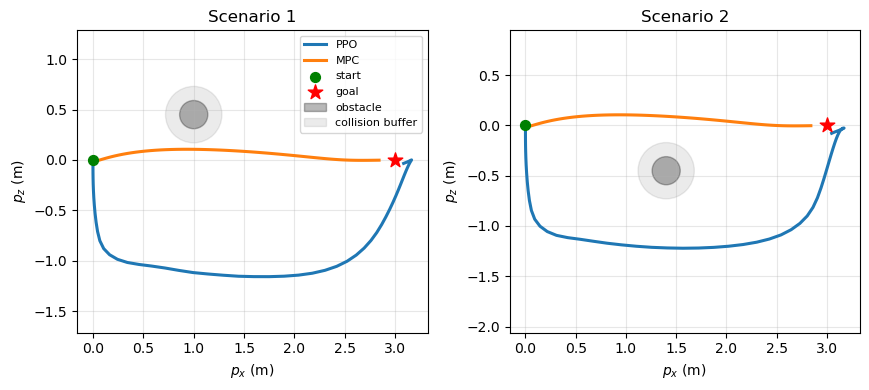

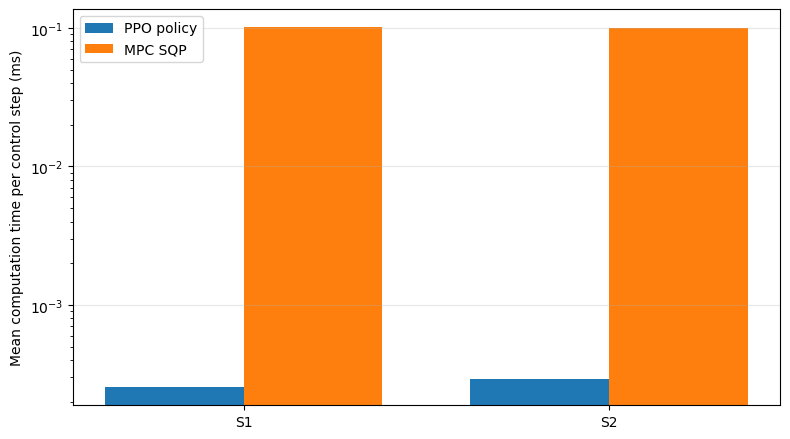


Discussion notes:
- PPO mean computation time: 0.0003 ms per control step.
- MPC mean computation time: 0.1005 ms per control step.
- MPC was about 369.0x slower online for these scenarios.
- The trajectory plot compares the closed-loop paths under exactly the same obstacle centers.
- PPO uses a learned reactive policy, so deployment is very fast. MPC replans by solving an SQP at each step, which is much more computationally expensive but explicitly optimizes over a local horizon.


In [ ]:
import time

from stable_baselines3 import PPO

# Choose which model to load
# The best model
best_model_path = os.path.join(dirname, 'best_model', 'best_model.zip')
trained_model = PPO.load(best_model_path, device='cpu')
print(f"Loaded best model: {best_model_path}")

# The final model after all training steps
#final_model_path = os.path.join(dirname, 'final_model.zip')
#trained_model = PPO.load(final_model_path, device='cpu')
#print(f"Loaded final model: {final_model_path}")


def compare_ppo_mpc(obstacle_center, model=trained_model, sim_time=5.0):
    obstacle_center = np.asarray(obstacle_center, dtype=np.float64)

    # Run PPO policy
    ppo_trajectories, _, ppo_comp_time_per_step = rollout_trained_policy(
        model,
        episodes=1,
        seed=None,
        obstacle_center=obstacle_center,
        x0=x_start,
        sim_time=sim_time,
        deterministic=True,
        record_computation_time=True,
    )
    ppo_result = ppo_trajectories[0]

    # Run MPC
    mpc_x_hist, mpc_u_hist, mpc_comp_time_per_step = run_mpc(obstacle_center, sim_time=sim_time, record_computation_time=True, verbose=False)

    mpc_result = {
        'x_hist': np.asarray(mpc_x_hist),
        'u_hist': np.asarray(mpc_u_hist),
        'computation_times': mpc_comp_time_per_step,
    }

    ppo_goal_distance = float(np.linalg.norm(ppo_result['x_hist'][-1, :2] - x_goal[:2]))
    mpc_goal_distance = float(np.linalg.norm(mpc_result['x_hist'][-1, :2] - x_goal[:2]))

    summary = {
        'obstacle_x': obstacle_center[0],
        'obstacle_z': obstacle_center[1],
        'ppo_steps': len(ppo_result['u_hist']),
        'ppo_return': float(np.sum(ppo_result['rewards'])),
        'ppo_status': ppo_result['final_info'].get('termination_reason', 'horizon_end'),
        'ppo_goal_distance': ppo_goal_distance,
        'mpc_steps': len(mpc_result['u_hist']),
        'mpc_goal_distance': mpc_goal_distance,
    }

    return {
        'obstacle_center': obstacle_center,
        'ppo': ppo_result,
        'mpc': mpc_result,
        'summary': summary,
        'ppo_comp_time_per_step': ppo_comp_time_per_step,
        'mpc_comp_time_per_step': mpc_comp_time_per_step,
    }


comparison_obstacles = np.array([
    [1.00,  0.45],
    [1.40, -0.45],
    #[1.80,  0.00],
    #[2.20,  0.45],
    #[2.45, -0.35],
], dtype=np.float64)

comparison_results = []
for scenario_idx, obstacle_center in enumerate(comparison_obstacles, start=1):
    print(f'Running scenario {scenario_idx}: obstacle={obstacle_center}')
    result = compare_ppo_mpc(obstacle_center, sim_time=5.0)
    result['scenario_idx'] = scenario_idx
    comparison_results.append(result)


fig, axes = plt.subplots(1, len(comparison_results), figsize=(4.4 * len(comparison_results), 4), squeeze=False)
for ax, result in zip(axes[0], comparison_results):
    obstacle_center = result['obstacle_center']
    ppo_x_hist = result['ppo']['x_hist']
    mpc_x_hist = result['mpc']['x_hist']

    ax.plot(ppo_x_hist[:, 0], ppo_x_hist[:, 1], label='PPO', linewidth=2.2, color='tab:blue')
    ax.plot(mpc_x_hist[:, 0], mpc_x_hist[:, 1], label='MPC', linewidth=2.2, color='tab:orange')
    ax.scatter([x_start[0]], [x_start[1]], c='green', s=50, label='start', zorder=5)
    ax.scatter([x_goal[0]], [x_goal[1]], c='red', marker='*', s=120, label='goal', zorder=5)
    ax.add_patch(plt.Circle(obstacle_center, r, color='black', alpha=0.28, label='obstacle'))
    ax.add_patch(plt.Circle(obstacle_center, 2.0 * r, color='black', alpha=0.08, label='collision buffer'))
    ax.set_title(f'Scenario {result["scenario_idx"]}')
    ax.set_xlabel('$p_x$ (m)')
    ax.set_ylabel('$p_z$ (m)')
    ax.set_xlim([-0.5, 3.6])
    ax.set_ylim([-1.5, 1.5])
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    if result['scenario_idx'] == 1:
        ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig(os.path.join(dirname, 'ppo_mpc_trajectory_comparison_5_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

scenario_labels = [f'S{result["scenario_idx"]}' for result in comparison_results]
ppo_time_ms = [result['ppo_comp_time_per_step'] for result in comparison_results]
mpc_time_ms = [result['mpc_comp_time_per_step'] for result in comparison_results]

x = np.arange(len(comparison_results))
width = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, ppo_time_ms, width, label='PPO policy')
ax.bar(x + width / 2, mpc_time_ms, width, label='MPC SQP')
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels)
ax.set_ylabel('Mean computation time per step (ms)')
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(dirname, 'ppo_mpc_computation_time_5_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

print()
print('Discussion notes:')
print(f'- PPO mean computation time: {np.mean(ppo_time_ms):.4f} ms per control step.')
print(f'- MPC mean computation time: {np.mean(mpc_time_ms):.4f} ms per control step.')
print(f'- MPC was about {np.mean(mpc_time_ms) / np.mean(ppo_time_ms):.1f}x slower online for these scenarios.')
print('- The trajectory plot compares the closed-loop paths under exactly the same obstacle centers.')
print('- PPO uses a learned reactive policy, so deployment is very fast. MPC replans by solving an SQP at each step, which is much more computationally expensive but explicitly optimizes over a local horizon.')


The table and plots above give the requested comparison. The PPO trajectory function fixes the initial state and goal, changes only the obstacle center, and records the policy inference time at each control step. The MPC timing is collected inside `compare_ppo_mpc(...)` while still using the existing `run_mpc(...)` function.
